### [ 분류 실습 : Fish 데이터셋 - ENSEMBLE Voting ]

- **목표**
    - 데이터 : fish.csv 
    - 품___종 : 모든 품종 Species
    - 피___처 : 모든 피쳐 Weight,Length,Diagonal,Height,Width
    - 학습종류 : 지도학습 - 분류
    - 학습방법 : 앙상블의 보팅 => 데이터셋 동일 + 다른 여러개 모델들 학습

    - 보팅의 결과 도출 방식
        * 하드 보팅 :  모든 모델들의 결과에서 다수결 결정 
        * 소프트 보팅 : 모들 모델들의 확률 결과를 클래스별로 평균 계산해서 평균이 가장 높은 것으로 결정

- **학습설계**
    - 모델 : SVC, KNeighborsClassifier, DecisionTreeClassifier => VotingClassifier

- **[0]모듈 로딩**

In [2]:
## 데이터 분석 관련
import os
import numpy as np
import pandas as pd

## 시각화 관련
import matplotlib.pyplot as plt
import koreanize_matplotlib

## ML 데이터셋 및 교차검증 
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold

## ML 전처리 관련
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import LabelEncoder

## ML 파이프라인 관련
from sklearn.pipeline import Pipeline

## ML 모델 관련
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm  import SVC 
from sklearn.ensemble import VotingClassifier

## ML 성능지표 관련
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

 - **[1] 데이터 준비**

In [3]:
## 데이터 준비
DATA_FILE = '../Data/Numbers/fish.csv'

## 데이터 로딩 => 첫번째 줄 컬럼명, 데이터 구분 쉼표(,) 
fishDF = pd.read_csv(DATA_FILE)

In [4]:
## 데이터 기본 정보 확인
fishDF.info()
fishDF.head(2)

## 클래스 개수 및 비율
print('클래스별 이름       : ', fishDF['Species'].value_counts().index )
print('클래스별 데이터 개수 : ', fishDF['Species'].value_counts().to_list())
print('클래스별 데이터 비율 : ', fishDF['Species'].value_counts(normalize=True).round(1).tolist())


<class 'pandas.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Species   159 non-null    str    
 1   Weight    159 non-null    float64
 2   Length    159 non-null    float64
 3   Diagonal  159 non-null    float64
 4   Height    159 non-null    float64
 5   Width     159 non-null    float64
dtypes: float64(5), str(1)
memory usage: 7.6 KB
클래스별 이름       :  Index(['Perch', 'Bream', 'Roach', 'Pike', 'Smelt', 'Parkki', 'Whitefish'], dtype='str', name='Species')
클래스별 데이터 개수 :  [56, 35, 20, 17, 14, 11, 6]
클래스별 데이터 비율 :  [0.4, 0.2, 0.1, 0.1, 0.1, 0.1, 0.0]


In [5]:
## 컬럼별 데이터 분포
fishDF.describe(include = 'all')

## -----------------------------------------------------------
## => 해석
## - Weight  컬럼 : 최소값 0 ---> 몇 개 존재. 이상치 
## - Species 컬럼 : str     ---> category 형변환 
##                 타겟 컬럼으로 LabelEncoding 진행
##                 고유값 7개 --> 다중 클래스 분류 | 불균형 데이터셋
## - 수치값 컬럼들 : 값 차이 크게 남 --> 스케일링 필요
## -----------------------------------------------------------

,Species,Weight,Length,Diagonal,Height,Width
count,159,159.000000,159.000000,159.000000,159.000000,159.000000
unique,7,NaN,NaN,NaN,NaN,NaN
top,Perch,NaN,NaN,NaN,NaN,NaN
freq,56,NaN,NaN,NaN,NaN,NaN
mean,NaN,398.326415,28.415723,31.227044,8.970994,4.417486
std,NaN,357.978317,10.716328,11.610246,4.286208,1.685804
min,NaN,0.000000,8.400000,8.800000,1.728400,1.047600
25%,NaN,120.000000,21.000000,23.150000,5.944800,3.385650
50%,NaN,273.000000,27.300000,29.400000,7.786000,4.248500
75%,NaN,650.000000,35.500000,39.650000,12.365900,5.584500


- **[2] 데이터셋 분리**

In [6]:
## 피쳐와 타겟 분리
featureDF = fishDF[fishDF.columns[1:]]
targetSR  = fishDF[fishDF.columns[0]]

print(f'[TRAIN] {featureDF.shape}, {targetSR.shape}')

[TRAIN] (159, 5), (159,)


In [7]:
## 훈련/테스트 데이터 셋 분리 => 클래스 비율유지 : stratify 매개변수 설정
X_train, X_test, y_train, y_test = train_test_split(featureDF, 
                                                    targetSR,
                                                    test_size=0.2,
                                                    shuffle = True,
                                                    random_state = 12,
                                                    stratify=targetSR)

In [8]:
print(f'[TRAIN]\n{X_train.shape}, {y_train.shape}')
print(f'클래스 개수: {y_train.value_counts().to_list()}\n')

print(f'[TEST]\n{X_test.shape}, {y_test.shape}')
print(f'클래스 개수: {y_test.value_counts().to_list()}\n')

[TRAIN]
(127, 5), (127,)
클래스 개수: [45, 28, 16, 13, 11, 9, 5]

[TEST]
(32, 5), (32,)
클래스 개수: [11, 7, 4, 4, 3, 2, 1]



- **[3] 데이터 전처리**

In [9]:
## ------------------------------------------
## 타겟 컬럼 인코딩 => Pipeline은 피쳐 처리
## ------------------------------------------
## 인코더 인스턴스 생성
lbEncoder  = LabelEncoder()

## 학습용 데이터셋 기반 인코딩 기준 설정 및 변환
y_train_en = lbEncoder.fit_transform(y_train)

## 학습용 데이터셋 기준으로 테스트 데이터셋 변환
y_test_en  = lbEncoder.transform(y_test)

## 인코더 정보 확인 : fit()통해서 저장된 정보
print(f'classes_ : {lbEncoder.classes_ }')


classes_ : ['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']


- **[4] 파이프라인 + 교차검증 + 튜닝 준비**

In [ ]:
## ---------------------------------------------------------
## 파이프라인 인스턴스 생성 : 전처리기(스케일러) + 모델
## ---------------------------------------------------------
## => 보팅 인스턴스 생성 - Hard Voting
votsModel = VotingClassifier(estimators=[('kModel',   KNeighborsClassifier()), 
                                         ('svcModel', SVC(class_weight='balanced')),
                                         ("dtModel",  DecisionTreeClassifier(random_state=42, 
                                                                             class_weight='balanced'))])
## => 파이프라인 인스턴스 생성
pipe = Pipeline(steps=[
    ('rbScaler', RobustScaler()),
    ('votModel', votsModel)
])

## 분류용 교차검증 인스턴스 생성
skFold = StratifiedKFold(shuffle=True, random_state=12)

## 하이퍼파라미터 설정 : 모델변수명_ _파라미터
## -> 각 모델별 하이퍼파라미터 설정
params = {'votModel__dtModel__criterion' : ['gini', 'entropy', 'log_loss'],
          'votModel__kModel__n_neighbors' : [5, 7, 9, 11, 20],
          'votModel__svcModel__C' : [0.1, 0.5, 1.0, 5] }


## 교차검증+튜닝 인스턴스 생성
## => 불균형 데이터셋 : 성능지표, 교차검증방식, 베스트 모델 선정 기준 - refit
tunning = GridSearchCV( pipe, 
                        cv=skFold, 
                        param_grid=params,
                        scoring=['f1_macro', 'f1_weighted'],
                        refit='f1_macro',
                        return_train_score=True)

tunning

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...tate=42))]))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'votModel__dtModel__criterion': ['gini', 'entropy', ...], 'votModel__kModel__n_neighbors': [5, 7, ...], 'votModel__svcModel__C': [0.1, 0.5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['f1_macro', 'f1_weighted']"
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1_macro'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter 

In [ ]:
## ----------------------------------------
## Pipe의 파라미터 확인 : get_params()
## ----------------------------------------
for key in pipe.get_params().keys():
    if 'dtModel' in key or 'kModel' in key or 'svcModel' in key:
        print(key)

votModel__kModel
votModel__svcModel
votModel__dtModel
votModel__kModel__algorithm
votModel__kModel__leaf_size
votModel__kModel__metric
votModel__kModel__metric_params
votModel__kModel__n_jobs
votModel__kModel__n_neighbors
votModel__kModel__p
votModel__kModel__weights
votModel__svcModel__C
votModel__svcModel__break_ties
votModel__svcModel__cache_size
votModel__svcModel__class_weight
votModel__svcModel__coef0
votModel__svcModel__decision_function_shape
votModel__svcModel__degree
votModel__svcModel__gamma
votModel__svcModel__kernel
votModel__svcModel__max_iter
votModel__svcModel__probability
votModel__svcModel__random_state
votModel__svcModel__shrinking
votModel__svcModel__tol
votModel__svcModel__verbose
votModel__dtModel__ccp_alpha
votModel__dtModel__class_weight
votModel__dtModel__criterion
votModel__dtModel__max_depth
votModel__dtModel__max_features
votModel__dtModel__max_leaf_nodes
votModel__dtModel__min_impurity_decrease
votModel__dtModel__min_samples_leaf
votModel__dtModel__min_samp

- **[5] 교차검증 + 튜닝 진행**

In [12]:
## 진행
tunning.fit(X_train, y_train_en)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...tate=42))]))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'votModel__dtModel__criterion': ['gini', 'entropy', ...], 'votModel__kModel__n_neighbors': [5, 7, ...], 'votModel__svcModel__C': [0.1, 0.5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['f1_macro', 'f1_weighted']"
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1_macro'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter 

- **[5] 교차검증+튜닝 결과**

In [13]:
## => 최고 파라미터, 최고 점수, 최고 모델 추출
print(f'best_params_ : {tunning.best_params_}')
print(f'best_score_  : {tunning.best_score_}')

## => 모델 인스턴스만 저장 
bestModel = tunning.best_estimator_.named_steps['votModel'].named_estimators_['dtModel']

print( f'n_features_in_       :  {bestModel.n_features_in_}')
print( f'n_features_in_       :  {X_train.columns}')
print( f'feature_importances_ :  {bestModel.feature_importances_}')
print( f'classes_name         :  {lbEncoder.classes_}')
print( f'classes_             :  {bestModel.classes_}')
print( f'n_classes_           :  {bestModel.n_classes_}')


best_params_ : {'votModel__dtModel__criterion': 'entropy', 'votModel__kModel__n_neighbors': 5, 'votModel__svcModel__C': 5}
best_score_  : 0.6932190866777332
n_features_in_       :  5
n_features_in_       :  Index(['Weight', 'Length', 'Diagonal', 'Height', 'Width'], dtype='str')
feature_importances_ :  [0.00699587 0.10791992 0.28450142 0.49382154 0.10676125]
classes_name         :  ['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']
classes_             :  [0 1 2 3 4 5 6]
n_classes_           :  7


In [18]:
## => 상세 학습/검증 결과 
cvDF = pd.DataFrame(tunning.cv_results_,
                    columns = [ 'mean_train_f1_macro', 'mean_test_f1_macro', 'mean_train_f1_weighted','mean_test_f1_weighted']
)
cvDF.head(3)

,mean_train_f1_macro,mean_test_f1_macro,mean_train_f1_weighted,mean_test_f1_weighted
0,0.811327,0.565290,0.860454,0.632413
1,0.926991,0.676751,0.935885,0.722466
2,0.956336,0.676751,0.952365,0.722466


- **[6] 테스트 진행**

In [22]:
## => 학습/테스트 데이터셋으로 평가 진행
## 예측값 추출
y_pre = tunning.best_estimator_.predict(X_test)

## 점수 계산
test_score  = tunning.best_estimator_.score(X_test, y_test_en)
train_score = tunning.best_estimator_.score(X_train, y_train_en)

print(f'훈__련 점수 : {train_score} , 테스트점수: {test_score}')

훈__련 점수 : 0.9606299212598425 , 테스트점수: 0.78125


,0,1,2,3,4,5,6
0,7,0,0,0,0,0,0
1,0,2,0,0,0,0,0
2,0,0,8,0,2,1,0
3,0,0,0,4,0,0,0
4,0,0,2,0,1,0,1
5,0,0,0,0,0,3,0
6,0,0,1,0,0,0,0


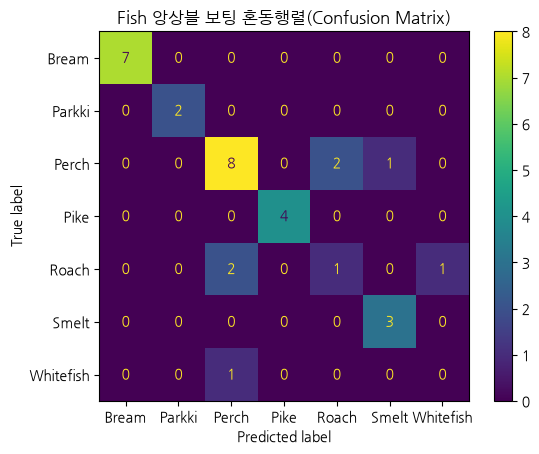

In [23]:
## => 혼동행렬 :  accuracy, precision, recall, f1-score 계산용 표
condata = confusion_matrix(y_test_en, y_pre)
conDF   = pd.DataFrame(condata)
display(conDF)

## => 시각화 : ConfusionMatrixDisplay()
##    클래스별 학습 정도 확인
disp = ConfusionMatrixDisplay(  confusion_matrix=condata,
                                display_labels=lbEncoder.classes_)

disp.plot()
plt.title("Fish 앙상블 보팅 혼동행렬(Confusion Matrix)")
plt.show()


In [24]:
## => 분류 성능 평가 보고서 보기
print( classification_report(y_test_en, y_pre, target_names=lbEncoder.classes_))

              precision    recall  f1-score   support

       Bream       1.00      1.00      1.00         7
      Parkki       1.00      1.00      1.00         2
       Perch       0.73      0.73      0.73        11
        Pike       1.00      1.00      1.00         4
       Roach       0.33      0.25      0.29         4
       Smelt       0.75      1.00      0.86         3
   Whitefish       0.00      0.00      0.00         1

    accuracy                           0.78        32
   macro avg       0.69      0.71      0.70        32
weighted avg       0.77      0.78      0.77        32

